# The PotentialT class - A time-dependant potential builder

In this tutorial, we are going to demonstrate the capabilities of the `PotentialT` class, a children class of the `Potential` class introduced in the `bloch_schrodinger` package, by constructing an implementation of [Thouless pumping](https://arxiv.org/pdf/2210.02050).

The objective of this class is to offer a convenient way to create potential landsscape discretized in space but analytical in time, to allow the efficient use of adaptative step methods for the propagation of the (Non-linear) Schrödinger equation.

## Structure of the class

The `PotentialT` class contains four main attribute:
+ The time-independant potential `V`, as in the `Potential` class (see its documentation for more informations), which is a (...,M,N) xarray.DataArray containing the potential landscape (a $N \times M) array for each point of the parameter space. 
+ The dictionary `timefuncs`, which contains the specifications of every functions $f_i(t)$ used do define $V(t)$.
+ The dictionary `shapes_t`, which contains every time-dependant spatial $shapes_i (\bf{r})$ of the Potential. Each value of this dictionary is a (..., N,M) xarray.DataArray, with parameter dimensions not neccessarily matching those of the time-independant part.
+ Finally the dictionnary `terms`, which contains string expressions describing the way shapes and time functions must be used together to create the time-dependant potential:
  
$$ V(t, \bf{r}) = V_0(\bf{r}) + \sum_j expr_j(\dots, f_i(t), \dots, \dots, shapes_i(\bf{r}), \dots)$$

Shapes and time functions are added to a `PotentialT` object by dedicated class methods, who all support the use of parameter dimensions for most of their arguments. Meanwhile, $V_0$ can be constructed using the regular methods of the `Potential` class. Once these shapes and functions are defined, the used only need to combine them together by adding terms to the `terms` attribute. As we are going to show.

## The Thouless pump

The Thouless pump is a periodic potential protocol that drives the quantified displacement of topological charges in a 1D lattice. In this tutorial, we are going to demonstrate its operation by building the potential function $V(t)$ and then by using it to move a bright soliton in a 1D lattice.

The Thouless pump potential can be expressed as the sum of two sinusoidal potentials:
$$ V(t, x) = V_s \sin^2(\pi x / d_s + \pi /2) + V_l \sin^2(\pi x / d_l + \phi /2) = V_s \sin^2(\pi x / d_s + \pi /2) + V_l\left[ 1 - \cos(2\pi x / d_l)\cos(\phi) - \sin(2\pi x / d_l)\sin(\phi)\right]/2$$

with $d_s = \alpha d_l, \: \alpha < 1$ and $\phi$ an arbitrary phase shift. One cycle of the Thouless pumping is realized when $\phi$ goes from 0 to $2\pi$. We are now going to build this potential, defining $\phi (t) = \omega_t t$.


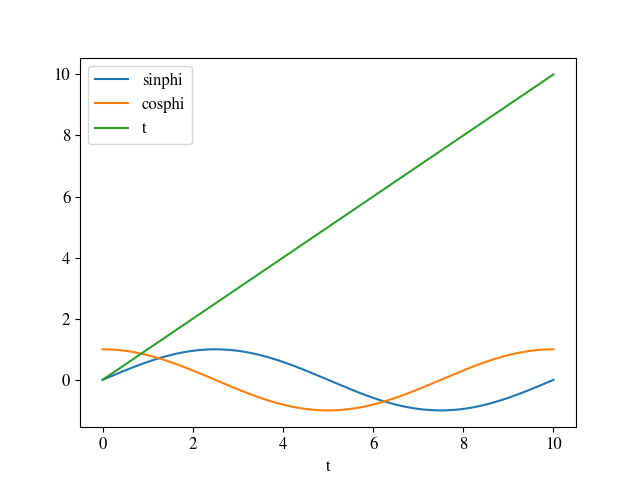

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import create_parameter
from BECs.potentialT import PotentialT

# --- Setting some parameters ---

V_s, V_l = 3, 3
d_l = 5
alpha = create_parameter('alpha', np.linspace(0.25,0.75, 3)) # We will explore multiple values of alpha
d_s = alpha * d_l

T = create_parameter('T', np.linspace(10, 20, 2))
omega_t = 2*np.pi/T # We also specify omega the reduced frequency of one pump cycle as a parameter dimension.

omega_y = 5 # the confining potential in y will be an harmonic trap of frequency omega_y

lx = d_l * 30 # length of the simulation box along x
ly = 10 # length of the simulation box along y

# --- Instanciating the PotentialT object --- 
pump = PotentialT( # A PotentialT object is instanciated the same way as a Potential object
    unitvecs= [[lx, 0], [0, ly]],
    resolution=(512, 64), # A large resolution along x and smaller along y
    v0 = 0 # no initial potential height
)

pump.add(omega_y**2 / 2 * pump.y**2) # We add the confinement along y, which is time independant 
pump.add(V_s * np.sin(np.pi * pump.x / d_s + np.pi / 2)) # The short potential part can be added as a time-indendant term
pump.add(V_l/2) # The long potential constant term can be also added now


# --- Adding the spatial shapes to the instance ---
# There is two time-dependant shape to add, one proportional to cos(phi), the other to sin(phi)

pump.add_shape('cosx', -V_l/2 * np.cos(2*np.pi * pump.x / d_l)) # These shapes can be added directly like so, or using higher-level functions such as circle_t or rectangle_t
pump.add_shape('sinx', -V_l/2 * np.sin(2*np.pi * pump.x / d_l)) # They need a name to be referenced when adding the various terms

# Now, we need to add the two time functions, sin(phi) and cos(phi), with phi = omega_t * t. We can use the 'sine' class method to create them

pump.sine("sinphi", omega = omega_t, phase = 0, amplitude = 1, mean = 0)
pump.sine("cosphi", omega = omega_t, phase = np.pi/2)

# Other time functions already coded are 'step', 'ramp', 'square' and 'gaussian'. Don't hesitate to make your own. The identity time function 't' is always already defined, for convenience.
# One can interactively visualize those time functions using the dedicated class method, with all parameter dimensions as sliders.
%matplotlib widget
pump.plot_timefunction(
    ["sinphi", "cosphi", "t"],
    tmin = 0, 
    tmax = 10,
    n_t = 500
)
plt.show()

Now that the shapes and time functions have been defined, we only have to combine them by adding expressions to the `terms` attribute. These expressions are strings containing regular python expressions. They can contain maths and numpy functions (using `np.` to call them).

In [18]:
pump.add_term("cosx * cosphi")
pump.add_term("sinx * sinphi")

Finally, we can visualize the resulting potential using the interactive `plot_t` class method:

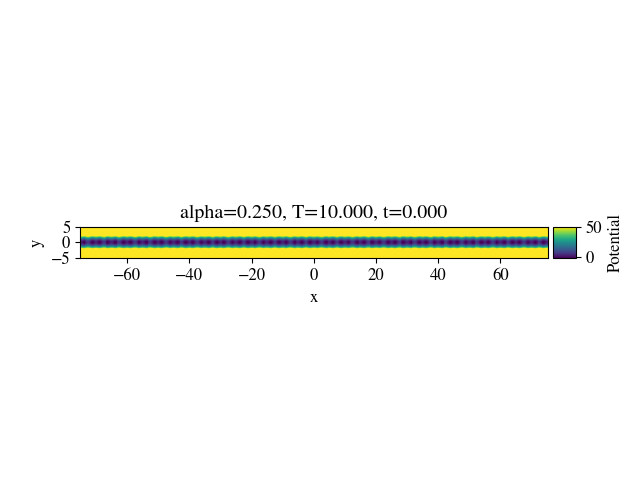

In [19]:
pump.plot_t(
    tmin = 0,
    tmax = 50,
    n_t=300,
    vmax = 50
)
plt.show()

we can also show a cut of this Hamitlonian by first converting it to a regular Potential object with time as a parameter dimension, and then using the 'plot_cuts' function.

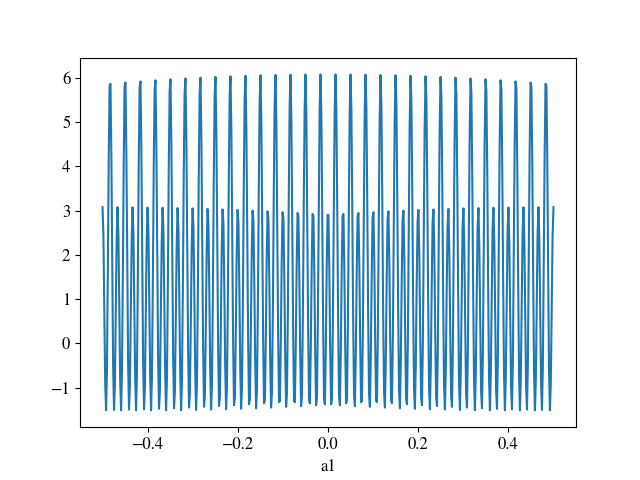

In [20]:
from bloch_schrodinger.plotting import plot_cuts

pump_pot = pump.to_potential(t_coord = (0,20,500))
plot_cuts(
    pump_pot.V.sel(a2 = 0, method = 'nearest'), # We take a cut along a2 = y = 0
    dim = 'a1',
    groupby=[]
)
plt.show()

In [21]:
from BECs.groundstate import GroundStateSSFM

pump_trap = pump.copy()
# pump_trap.add((omega_y/30)**2 / 2 * pump.x**2)

alpha = 0.5
g = 0

grd = GroundStateSSFM(
    pump_trap.to_potential(t = 0),
    alpha = 0.5,
    g = g
)

energy, psi0 = grd.solve(
    population = 1, parallelize=True, n_cores=6
)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   11.3s remaining:   11.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   34.1s finished


Reshaping and storing


100%|██████████| 6/6 [00:00<00:00, 1116.35it/s]


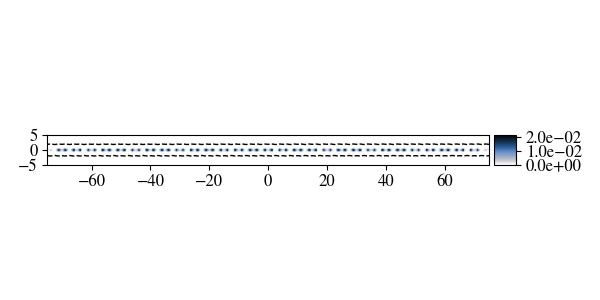

In [22]:
from bloch_schrodinger.plotting import plot_eigenvector

plot_eigenvector(
    [[abs(psi0)**2]],
    [[pump.to_potential(t = 0)]],
    [['amplitude']]
)
plt.show()

In [ ]:
%reload_ext autoreload
%autoreload 2

from BECs.ssfm import SSFM

solv = SSFM(
    pump, psi0, alpha, g
)
ti, tf = 0, 200
t_samples = create_parameter("t", np.linspace(ti, tf, 200))

psi = solv.solve(ti, tf, t_samples, tol = 1e-6, verbose=True, parallelize=True)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


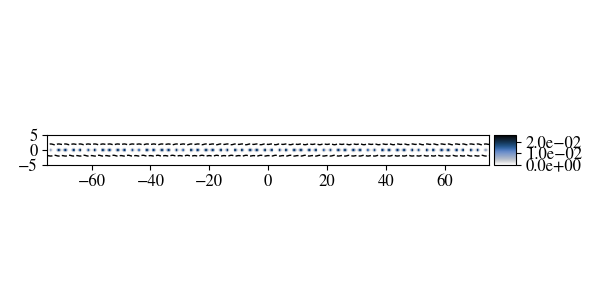

In [ ]:
plot_eigenvector(
    [[abs(psi)**2]],
    [[pump.to_potential(t_coord = t_samples)]],
    [['amplitude']]
)
plt.show()